In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load the dataset
data = pd.read_csv('../../data/auto-mpg.csv')
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
# Cleaning the dataset
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')
df_clean = (
    data.drop(columns=['origin', 'car name']) # Drop non-numeric columns
    .rename(columns={'model year': 'model_year'})
    .dropna()
    .reset_index(drop=True) # Reset index after dropping rows
)

df_clean.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [4]:
TARGET = 'mpg'
quan_categories = ['displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

In [5]:
df_clean[quan_categories].describe()

,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000
mean,194.411990,104.469388,2977.584184,15.541327,75.979592
std,104.644004,38.491160,849.402560,2.758864,3.683737
min,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,275.750000,126.000000,3614.750000,17.025000,79.000000
max,455.000000,230.000000,5140.000000,24.800000,82.000000


# Exploratory Data Analysis (EDA)

## Uni-variate Analysis

In [6]:
cols = [TARGET] + quan_categories

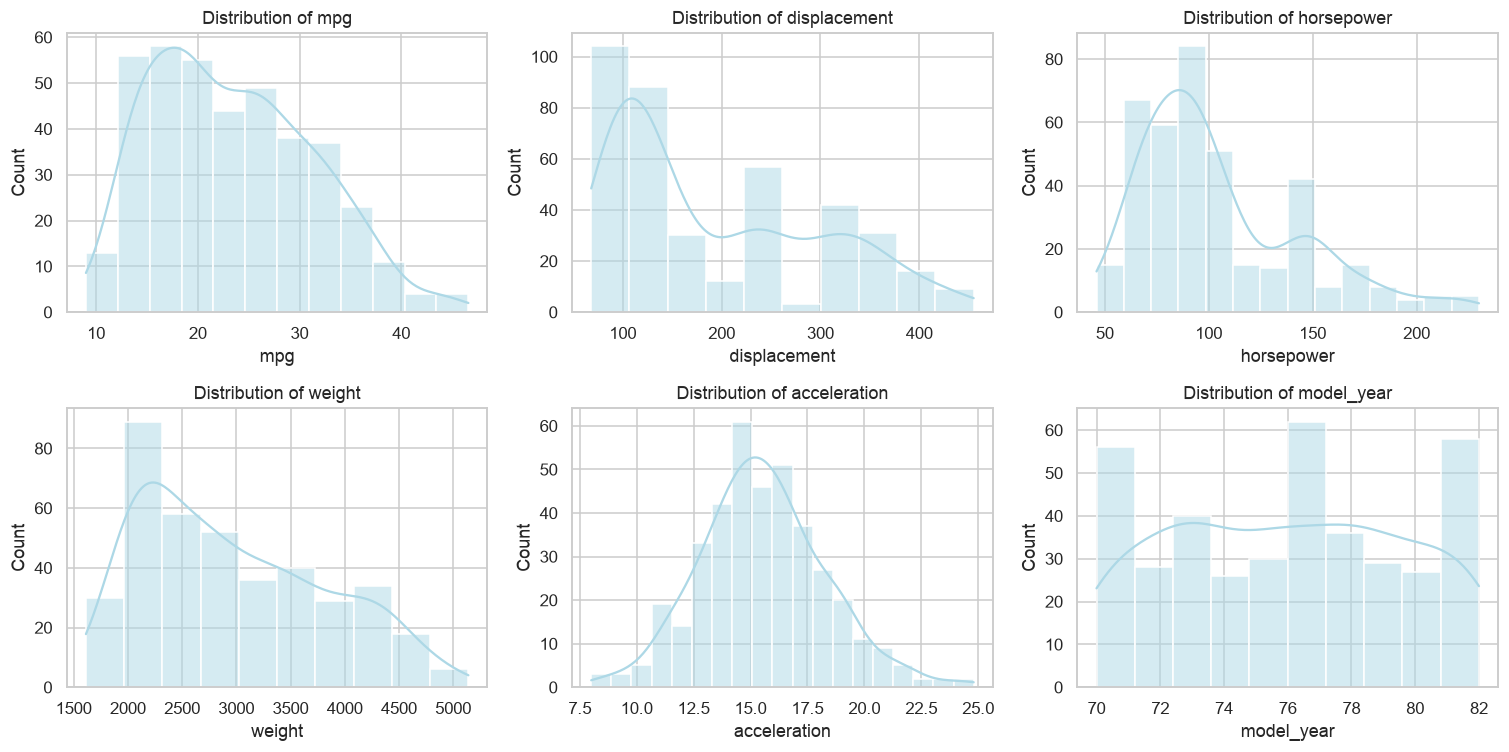

In [7]:
# Histograms to check the distribution of each variable
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.histplot(df_clean[c], ax=axes[i], kde=True, color='lightblue')
    axes[i].set_title(f'Distribution of {c}')
plt.tight_layout()
plt.show()

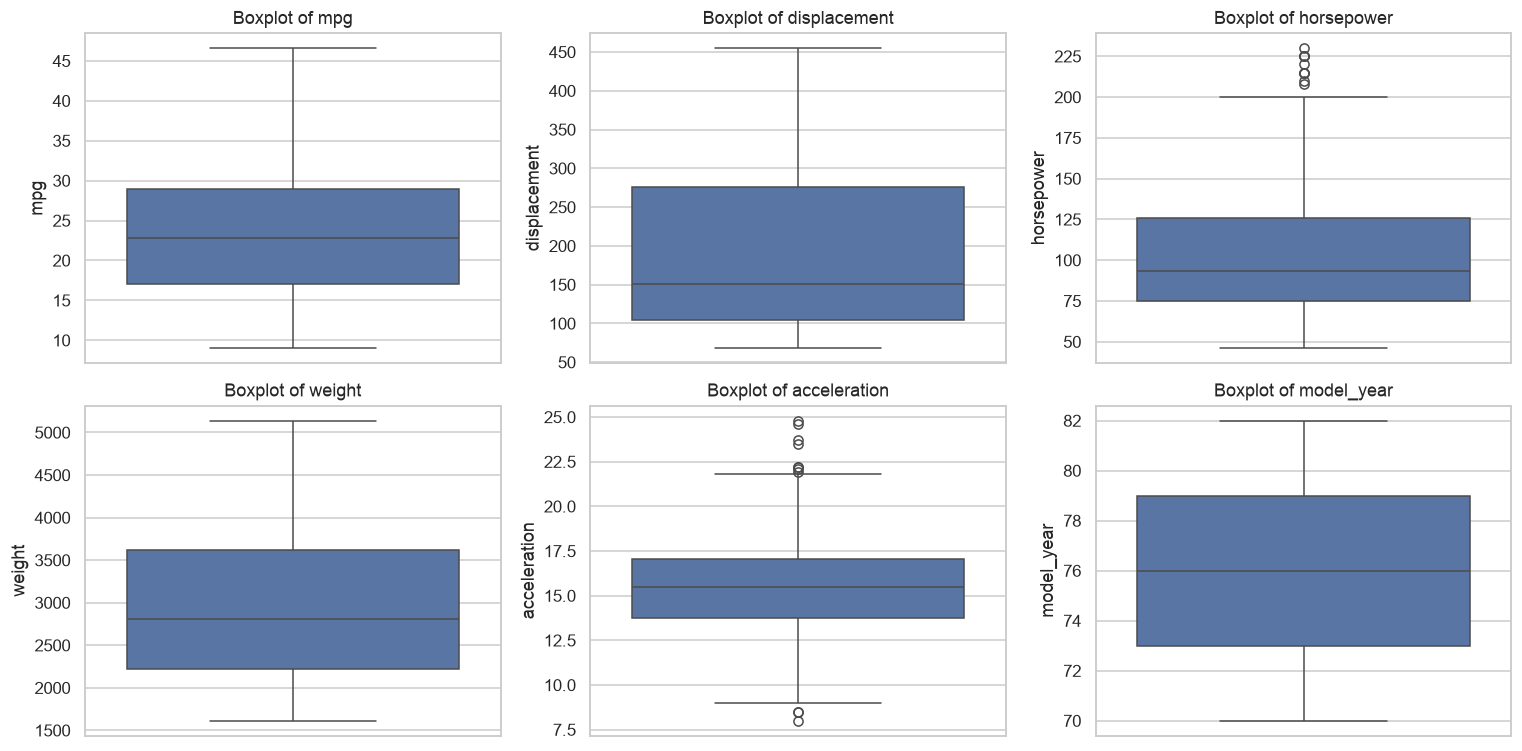

In [8]:
# Boxplots to check for outliers in each variable
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.boxplot(y=df_clean[c], ax=axes[i])
    axes[i].set_title(f'Boxplot of {c}')
plt.tight_layout()
plt.show()

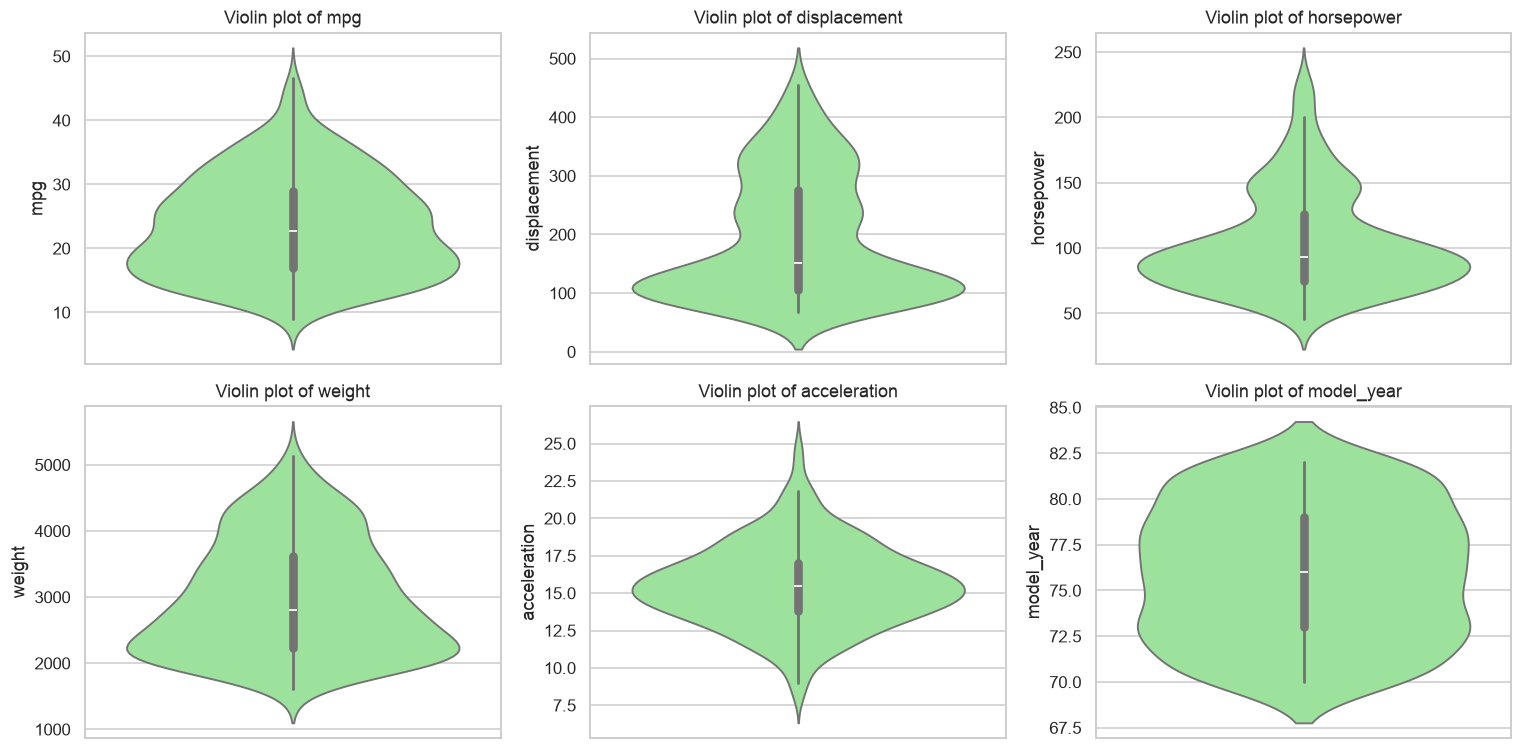

In [9]:
# Violin plots to visualize the distribution and density of each variable
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.violinplot(y=df_clean[c], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Violin plot of {c}')
plt.tight_layout()
plt.show()

In [10]:
# Skewness of the variables
df_clean.skew()

mpg             0.457092
cylinders       0.508109
displacement    0.701669
horsepower      1.087326
weight          0.519586
acceleration    0.291587
model_year      0.019688
dtype: float64

## Bivariate Analysis

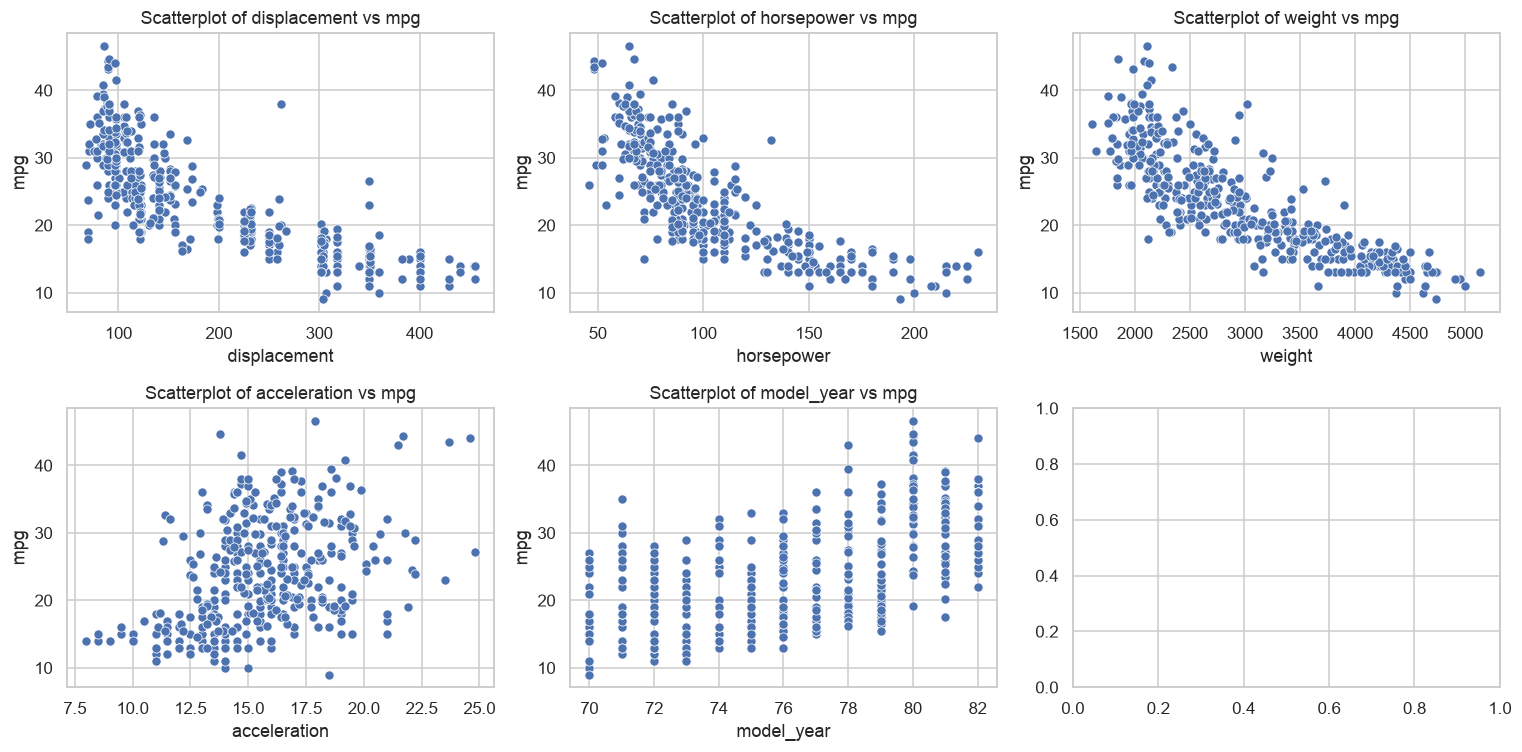

In [11]:
# Scatterplots to visualize the relationship between each feature and the target variable
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(quan_categories):
    sns.scatterplot(x=df_clean[c], y=df_clean[TARGET], ax=axes[i])
    axes[i].set_title(f'Scatterplot of {c} vs {TARGET}')
plt.tight_layout()
plt.show()

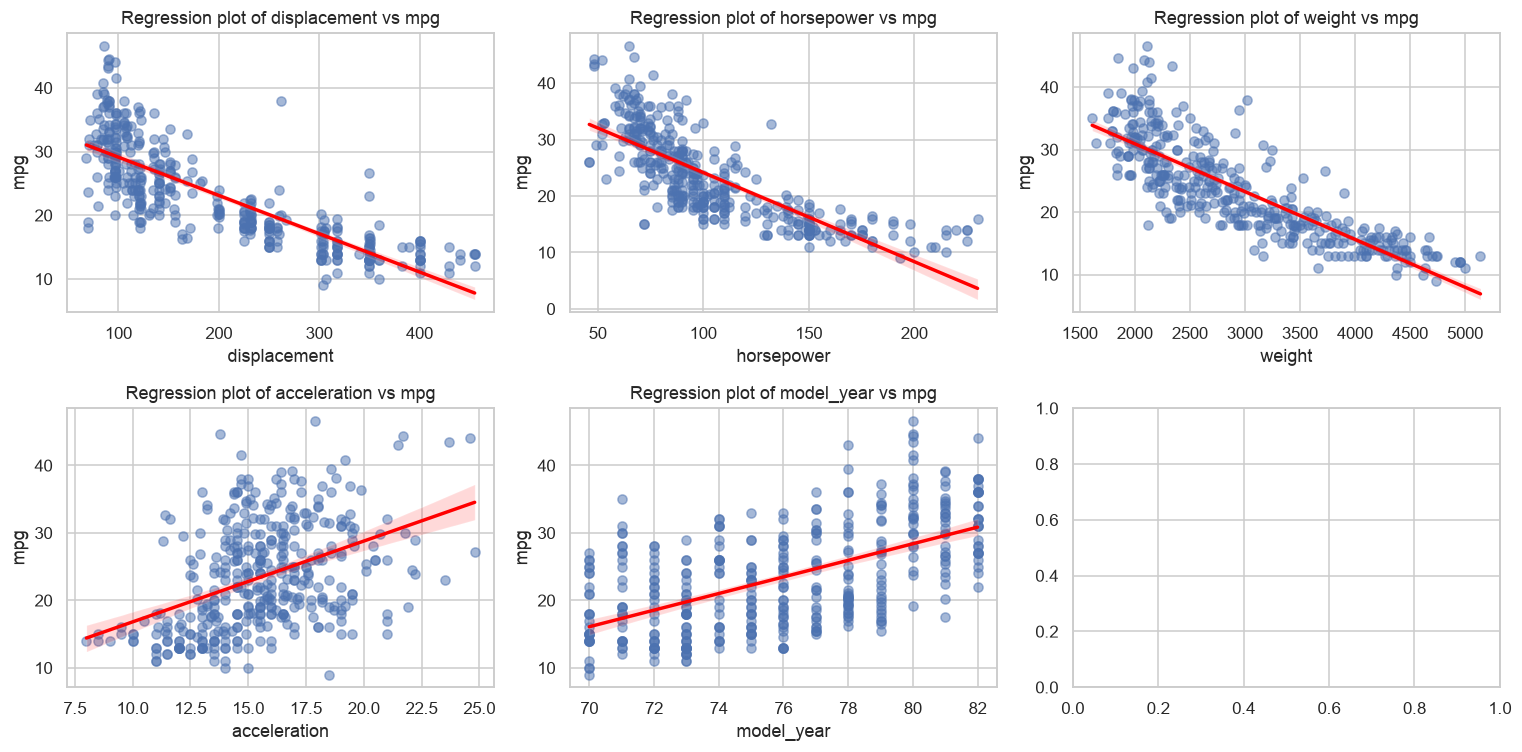

In [12]:
# Regression plots to visualize the linear relationship between each feature and the target variable
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(quan_categories):
    sns.regplot(x=df_clean[c], y=df_clean[TARGET], ax=axes[i], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[i].set_title(f'Regression plot of {c} vs {TARGET}')
plt.tight_layout()
plt.show()

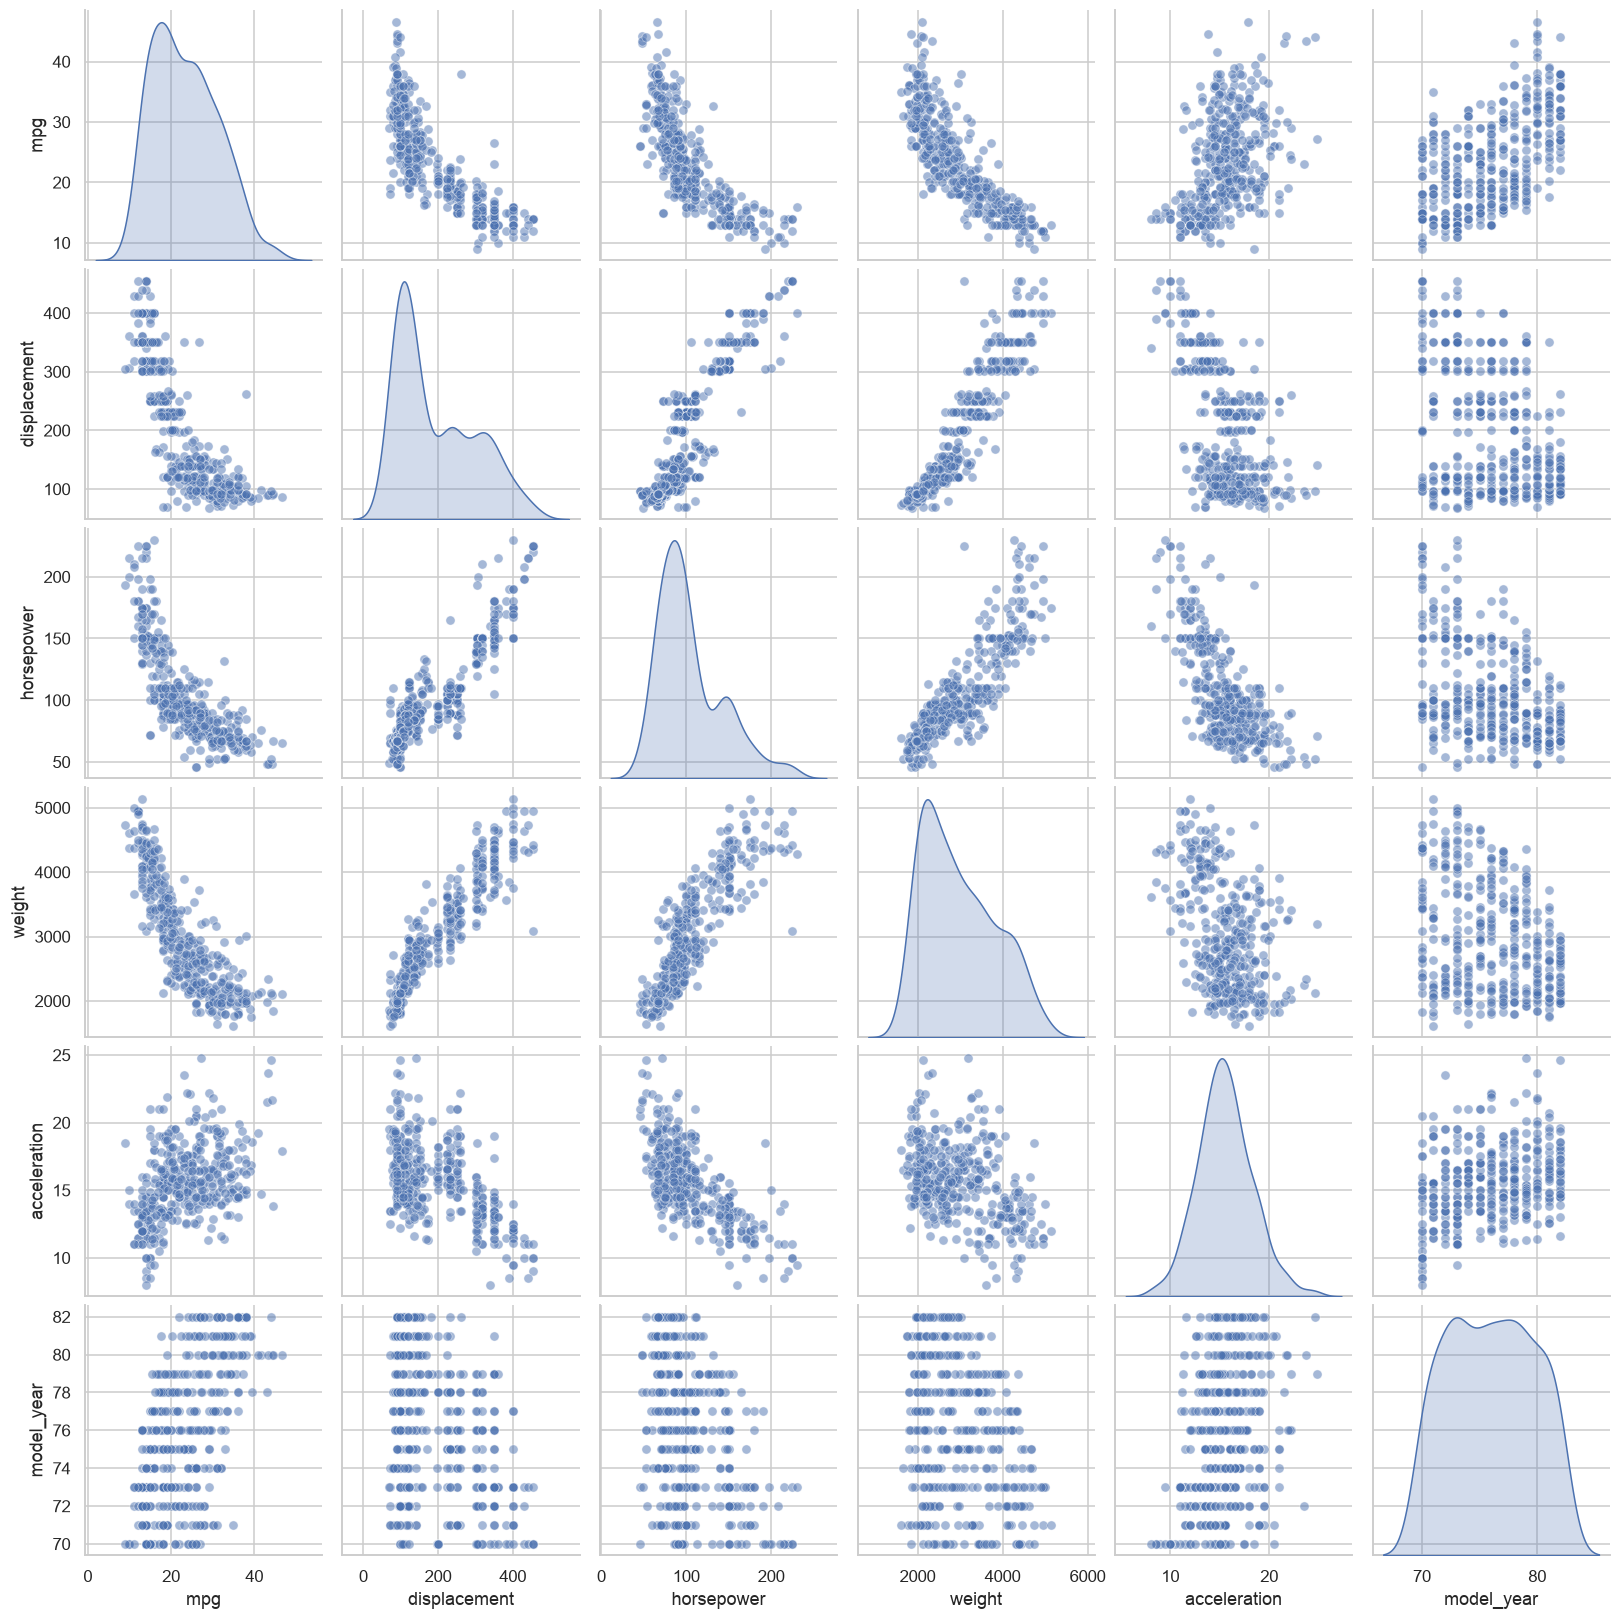

In [13]:
# Pairplot to visualize pairwise relationships between features and the target variable
sns.pairplot(df_clean[cols], diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

## Correlation Analysis

In [14]:
# Pearson correlation matrix to quantify the linear relationships between features and the target variable
correlation_matrix = df_clean[cols].corr()
correlation_matrix

,mpg,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.805127,-0.778427,-0.832244,0.423329,0.580541
displacement,-0.805127,1.000000,0.897257,0.932994,-0.543800,-0.369855
horsepower,-0.778427,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.832244,0.932994,0.864538,1.000000,-0.416839,-0.309120
acceleration,0.423329,-0.543800,-0.689196,-0.416839,1.000000,0.290316
model_year,0.580541,-0.369855,-0.416361,-0.309120,0.290316,1.000000


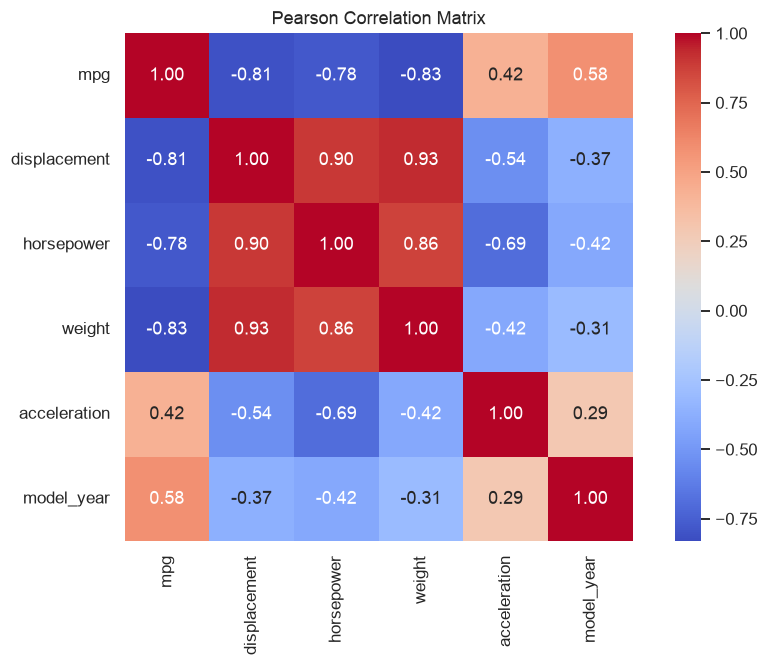

In [15]:
# Heatmap of Pearson correlation matrix to visualize the strength of linear relationships
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Pearson Correlation Matrix')
plt.show()